## Initialization

In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=0AgIk8gteZagNKWERmNVIqwkbe3aAM&access_type=offline&code_challenge=pSReSHEEJb8WegIhC1QR3K-kJEZIt92ujY46H2PQ78Y&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning

In [1]:
import os
import numpy as np

import hail as hl
import pyspark.sql.functions as f
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_index import StudyIndex
from gentropy.method.window_based_clumping import WindowBasedClumping
from gentropy.susie_finemapper import SusieFineMapperStep

hail_dir = os.path.dirname(hl.__file__)
session = Session(hail_home=hail_dir, start_hail=True, extended_spark_conf={"spark.driver.memory": "12g",
    "spark.kryoserializer.buffer.max": "500m","spark.driver.maxResultSize":"3g"})
hl.init(sc=session.spark.sparkContext, log="/dev/null")

Loading BokehJS ...

24/07/11 09:39:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


24/07/11 09:39:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


pip-installed Hail requires additional configuration options in Spark referring
  to the path to the Hail Python module directory HAIL_DIR,
  e.g. /path/to/python/site-packages/hail:
    spark.jars=HAIL_DIR/backend/hail-all-spark.jar
    spark.driver.extraClassPath=HAIL_DIR/backend/hail-all-spark.jar
    spark.executor.extraClassPath=./hail-all-spark.jarRunning on Apache Spark version 3.3.4
SparkUI available at http://mib118093s.internal.sanger.ac.uk:4041
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.127-bb535cd096c5
LOGGING: writing to /dev/null


In [2]:
qc1=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/gwas_cat_qc_results_qc1")
qc5=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/gwas_cat_qc_results_qc5")

In [3]:
qc1.count()

13227

In [4]:
qc5.count()

13227

In [6]:
df = (
qc1.join(qc5, on="studyId", how="outer")
)

In [7]:
df.count()

13227

In [8]:
df_pan = df.toPandas()

In [9]:
df_pan

,studyId,mean_beta,n_variants,n_variants_sig
0,GCST000568,0.000073,2445760,290
1,GCST000569,-0.000186,2392760,4
2,GCST000571,0.000017,2437420,0
3,GCST000612,-0.000225,518292,55
4,GCST000679,0.000144,2228924,3758
...,...,...,...,...
13222,GCST90309929,0.000051,1347654,15078
13223,GCST90309930,-0.000025,1347165,3565
13224,GCST90310294,-0.000462,7544789,94300
13225,GCST90310295,-0.000252,7555192,96418


In [10]:
list_to_qc=pd.read_csv("gs://genetics-portal-dev-analysis/yt4/list_of_ids_to_qc_20240710.txt",header=None)
list_to_qc=list_to_qc[0].tolist()

In [11]:
# Assuming list_to_qc is your list of studies
studies_in_df = set(df_pan['studyId'].tolist())
studies_not_in_df = set(list_to_qc) - studies_in_df

print(studies_not_in_df)

{'GCST90079310', 'GCST90177226', 'GCST90177241', 'GCST90013537', 'GCST90080069', 'GCST90078189', 'GCST90077818', 'GCST90199915', 'GCST90078064', 'GCST90080411', 'GCST90078027', 'GCST90078222', 'GCST90199827', 'GCST90243586', 'GCST90177091', 'GCST90176119', 'GCST90176858', 'GCST90202142', 'GCST90302129', 'GCST90080645', 'GCST90077607', 'GCST90079382', 'GCST90081203', 'GCST90077720', 'GCST90243519', 'GCST90202376', 'GCST90078526', 'GCST90176624', 'GCST90079176', 'GCST90081384', 'GCST90199988', 'GCST90078516', 'GCST90079389', 'GCST90081145', 'GCST90199837', 'GCST90079961', 'GCST006957', 'GCST90077565', 'GCST006390', 'GCST90203475', 'GCST90081436', 'GCST90079860', 'GCST90202268', 'GCST90203331', 'GCST90079782', 'GCST90204045', 'GCST90077576', 'GCST90078386', 'GCST90203410', 'GCST90077886', 'GCST90080075', 'GCST90010793', 'GCST90079629', 'GCST90013540', 'GCST90080627', 'GCST90079830', 'GCST90199815', 'GCST90204039', 'GCST90201727', 'GCST90199888', 'GCST90177395', 'GCST90079199', 'GCST006550

In [29]:
len(studies_not_in_df)

7112

In [28]:
path="gs://gwas_catalog_data/harmonised_summary_statistics/"
suff=".parquet/"
x='GCST011344'
x=SummaryStatistics.from_parquet(session,path + x + suff)
y=x.sanity_filter()

ValueError: Parquet file is empty: gs://gwas_catalog_data/harmonised_summary_statistics/GCST011344.parquet/

In [30]:
path="gs://gwas_catalog_data/harmonised_summary_statistics/"
suff=".parquet/"
x='GCST90177230'
x=SummaryStatistics.from_parquet(session,path + x + suff)
y=x.sanity_filter()

In [31]:
x.df.show()

+------------+------------------+----------+---------+---------+----------+--------------+--------------+-------------------------------+-------------+
|     studyId|         variantId|chromosome| position|     beta|sampleSize|pValueMantissa|pValueExponent|effectAlleleFrequencyFromSource|standardError|
+------------+------------------+----------+---------+---------+----------+--------------+--------------+-------------------------------+-------------+
|GCST90177230|   19_13188255_T_C|        19| 13188255|-0.174597|      null|         1.771|            -3|                           null|         null|
|GCST90177230|    18_8336966_C_T|        18|  8336966|-0.424963|      null|         6.421|            -4|                           null|         null|
|GCST90177230|    16_6989955_C_T|        16|  6989955| -1.16022|      null|         2.135|            -3|                           null|         null|
|GCST90177230|   17_16899574_C_T|        17| 16899574| 0.178722|      null|         3.94

In [32]:
y.df.show()

+-------+---------+----------+--------+----+----------+--------------+--------------+-------------------------------+-------------+
|studyId|variantId|chromosome|position|beta|sampleSize|pValueMantissa|pValueExponent|effectAlleleFrequencyFromSource|standardError|
+-------+---------+----------+--------+----+----------+--------------+--------------+-------------------------------+-------------+
+-------+---------+----------+--------+----+----------+--------------+--------------+-------------------------------+-------------+



In [33]:
summary = df_pan['n_variants'].describe()
print(summary)

count    1.322700e+04
mean     1.100662e+07
std      6.267151e+06
min      5.520000e+03
25%      7.700434e+06
50%      1.179639e+07
75%      1.376467e+07
max      6.016326e+07
Name: n_variants, dtype: float64


In [34]:
summary = df_pan['mean_beta'].abs().describe()
print(summary)

count    1.322700e+04
mean     3.784699e+07
std      4.888700e+08
min      2.967770e-10
25%      5.493181e-05
50%      1.950281e-04
75%      8.038900e-04
max      2.575421e+10
Name: mean_beta, dtype: float64


In [35]:
sum(df_pan['mean_beta'].abs() <= 0.01)/len(df_pan)

0.9337718303470175

In [39]:
x=(df_pan['mean_beta'].abs() <= 0.05) & (df_pan['n_variants'] >= 2e6)

In [40]:
sum(x)

11125

In [41]:
df_pan[x]

,studyId,mean_beta,n_variants,n_variants_sig
0,GCST000568,0.000073,2445760,290
1,GCST000569,-0.000186,2392760,4
2,GCST000571,0.000017,2437420,0
4,GCST000679,0.000144,2228924,3758
5,GCST000755,0.000055,2627262,2202
...,...,...,...,...
13109,GCST90308603,0.000329,17794783,20145
13111,GCST90308774,-0.000111,9540863,1232
13224,GCST90310294,-0.000462,7544789,94300
13225,GCST90310295,-0.000252,7555192,96418


In [43]:
df_pan[x].to_csv("~/gwas_cat_qc_results_clean_20240711.csv", index=False)

In [21]:
import numpy as np

# Check which elements in the 'mean_beta' column are infinite
infinite_elements = np.isinf(df_pan['mean_beta'])

print(sum(infinite_elements))
df_pan[infinite_elements]


3


,studyId,mean_beta,n_variants,n_variants_sig
455,GCST012234,inf,6743765,0
1858,GCST90013939,inf,11038580,2707
1890,GCST90013971,inf,11039165,1357


In [22]:
#x=SummaryStatistics.from_parquet(session,"gs://gwas_catalog_data/harmonised_summary_statistics/GCST012234.parquet")

In [23]:
#x_pd=x.df.toPandas()

In [24]:
#infinite_elements = np.isinf(x_pd['beta'])

In [25]:
#x_pd[infinite_elements]

In [33]:
x=session.spark.read.parquet("gs://genetics-portal-dev-data/22.09.1/outputs/v2d_credset/")

In [36]:
x.printSchema()

root
 |-- bio_feature: string (nullable = true)
 |-- gene_id: string (nullable = true)
 |-- is95_credset: boolean (nullable = true)
 |-- is99_credset: boolean (nullable = true)
 |-- lead_alt: string (nullable = true)
 |-- lead_chrom: string (nullable = true)
 |-- lead_pos: long (nullable = true)
 |-- lead_ref: string (nullable = true)
 |-- lead_variant_id: string (nullable = true)
 |-- logABF: double (nullable = true)
 |-- multisignal_method: string (nullable = true)
 |-- phenotype_id: string (nullable = true)
 |-- postprob: double (nullable = true)
 |-- postprob_cumsum: double (nullable = true)
 |-- study_id: string (nullable = true)
 |-- tag_alt: string (nullable = true)
 |-- tag_beta: double (nullable = true)
 |-- tag_beta_cond: double (nullable = true)
 |-- tag_chrom: string (nullable = true)
 |-- tag_pos: long (nullable = true)
 |-- tag_pval: double (nullable = true)
 |-- tag_pval_cond: double (nullable = true)
 |-- tag_ref: string (nullable = true)
 |-- tag_se: double (nullable =

In [38]:
x.show()

+--------------------+---------------+------------+------------+-------------------+----------+---------+--------+--------------------+------------------+------------------+--------------------+-----------------+-----------------+----------------+-------+------------------+-----------------+---------+---------+-----------------+----------------+-------+-----------------+-----------------+-------------------+----+
|         bio_feature|        gene_id|is95_credset|is99_credset|           lead_alt|lead_chrom| lead_pos|lead_ref|     lead_variant_id|            logABF|multisignal_method|        phenotype_id|         postprob|  postprob_cumsum|        study_id|tag_alt|          tag_beta|    tag_beta_cond|tag_chrom|  tag_pos|         tag_pval|   tag_pval_cond|tag_ref|           tag_se|      tag_se_cond|     tag_variant_id|type|
+--------------------+---------------+------------+------------+-------------------+----------+---------+--------+--------------------+------------------+------------

In [39]:
unique_values = x.select('type').distinct()
unique_values.show()

+----+
|type|
+----+
|gwas|
|sqtl|
|pqtl|
|eqtl|
+----+



In [43]:
y=x.filter(x.type == 'gwas' & x.is99_credset == True)
unique_count = y.select('lead_variant_id').distinct().count()
print(unique_count)

Py4JError: An error occurred while calling o139.and. Trace:
py4j.Py4JException: Method and([class java.lang.String]) does not exist
	at py4j.reflection.ReflectionEngine.getMethod(ReflectionEngine.java:318)
	at py4j.reflection.ReflectionEngine.getMethod(ReflectionEngine.java:326)
	at py4j.Gateway.invoke(Gateway.java:274)
	at py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:132)
	at py4j.commands.CallCommand.execute(CallCommand.java:79)
	at py4j.ClientServerConnection.waitForCommands(ClientServerConnection.java:182)
	at py4j.ClientServerConnection.run(ClientServerConnection.java:106)
	at java.base/java.lang.Thread.run(Thread.java:829)



In [32]:
sum(df_pan['mean_beta'].abs() <= 0.02)/len(df_pan)

0.9392164042475284

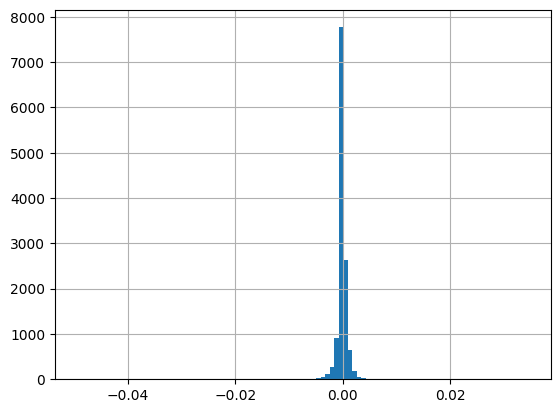

In [31]:
import matplotlib.pyplot as plt

# Create a histogram of the 'mean_beta' column

df_filtered = df_pan[df_pan['mean_beta'].abs() <= 0.05]
df_filtered['mean_beta'].hist(bins=100)

# Show the plot
plt.show()

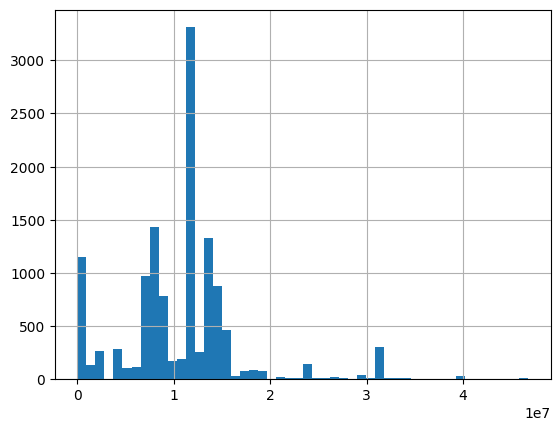

In [22]:
import matplotlib.pyplot as plt

# Create a histogram of the 'mean_beta' column

df_filtered['n_variants'].hist(bins=50)

# Show the plot
plt.show()